# Exercise 1

## Supervised Learning- Regression Models


---

## Overview

Welcome to this excercise. We are now going to use our new skills to build our supervised learning models that use a regression approach.

---


In [1]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os

# Manually set the path relative to the py file's location that you want to import
func_lib_path = os.path.abspath(
    os.path.join(os.getcwd(), ".")
)  # Add the path to sys.path
sys.path.append(func_lib_path)

# Now you can import func_lib
import func_lib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [3]:
# Retrieve historical price data.
# - Use the 'createHistPrices()' function from 'func_lib' to get historical price data.
# - Assign the result to the variable 'historical_prices'.

historical_prices = func_lib.create_hist_prices()

# Define the list of momentum periods.
# - Create a list containing different time periods for calculating momentum indicators.
# - Assign this list to the variable 'list_of_momentums'.

list_of_momentums = [1, 5, 15, 20]

# Compute returns based on historical prices and momentum periods.
# - Use the 'computingReturns()' function from 'func_lib' with 'historical_prices' and 'list_of_momentums' as inputs.
# - Assign the result to the variable 'total_returns'.

total_returns = func_lib.compute_returns(historical_prices, list_of_momentums)

# Remove any rows with missing values from the returns data.
# - Use the 'dropna()' method to remove rows with NaN values from 'total_returns'.
# - Apply the change in place to modify the DataFrame directly.

total_returns.dropna(inplace=True)

[**********************51%                       ]  255 of 501 completed$Q: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-05-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1714536000")
[**********************55%*                      ]  274 of 501 completed$SNDK: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-05-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1714536000")
[*********************100%***********************]  501 of 501 completed

2 Failed downloads:
['Q', 'SNDK']: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-05-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1714536000")


In [4]:
total_returns.head()

F_1_d_returns  1_d_returns  5_d_returns  15_d_returns  \
Ticker Date                                                                
A      2000-02-01       0.077465     0.072711     0.048938      0.029919   
       2000-02-02       0.016340     0.077465     0.119854      0.125000   
       2000-02-03      -0.019293     0.016340     0.136073      0.166980   
       2000-02-04       0.042623    -0.019293     0.120294      0.127541   
       2000-02-07      -0.006289     0.042623     0.201134      0.162705   

                   20_d_returns  
Ticker Date                      
A      2000-02-01     -0.013889  
       2000-02-02      0.150376  
       2000-02-03      0.246493  
       2000-02-04      0.270833  
       2000-02-07      0.223077

In [5]:
# Determine the split index for 70% of the dates.
# - Extract the unique dates from the index of 'total_returns'.
# - Calculate the split date by indexing into the unique dates to get the date corresponding to 70% of the total length of unique dates.
# - Assign this date to the variable 'split_date' and display it.

unique_dates = total_returns.index.get_level_values("Date").unique()
split_date = unique_dates[int(0.7 * len(unique_dates))]
print(split_date)

2017-01-20 00:00:00


In [6]:
# Create the training set: all data before the split date.
# - Use the 'loc[]' indexer to select rows from 'total_returns' where the date in the index is earlier than 'split_date'.
# - Assign this subset of data to the variable 'train_data'.
train_data = total_returns.loc[
    total_returns.index.get_level_values("Date") < split_date
]
print(train_data.head())

# Create the testing set: all data from the split date onwards.
# - Use the 'loc[]' indexer to select rows from 'total_returns' where the date in the index is equal to or later than 'split_date'.
# - Assign this subset of data to the variable 'test_data'.
test_data = total_returns.loc[
    total_returns.index.get_level_values("Date") >= split_date
]
print(test_data.head())

                   F_1_d_returns  1_d_returns  5_d_returns  15_d_returns  \
Ticker Date                                                                
A      2000-02-01       0.077465     0.072711     0.048938      0.029919   
       2000-02-02       0.016340     0.077465     0.119854      0.125000   
       2000-02-03      -0.019293     0.016340     0.136073      0.166980   
       2000-02-04       0.042623    -0.019293     0.120294      0.127541   
       2000-02-07      -0.006289     0.042623     0.201134      0.162705   

                   20_d_returns  
Ticker Date                      
A      2000-02-01     -0.013889  
       2000-02-02      0.150376  
       2000-02-03      0.246493  
       2000-02-04      0.270833  
       2000-02-07      0.223077  
                   F_1_d_returns  1_d_returns  5_d_returns  15_d_returns  \
Ticker Date                                                                
A      2017-01-20      -0.004830    -0.000420    -0.018549      0.044573   
 

In [7]:
# Extract the target variable for testing.
# - Select the 'F_1_d_returns' column from the 'test_data' DataFrame.
# - Assign this column to the variable 'total_returns'.
total_returns = test_data["F_1_d_returns"]
total_returns.head()

Ticker  Date      
A       2017-01-20   -0.004830
        2017-01-23   -0.000844
        2017-01-24    0.022386
        2017-01-25   -0.004958
        2017-01-26    0.009965
Name: F_1_d_returns, dtype: float64

In [8]:
# Define the feature and target columns.
# - List the names of the feature columns in 'features'.
# - List the name of the target column in 'target'.
features = ["1_d_returns", "5_d_returns", "15_d_returns", "20_d_returns"]
target = ["F_1_d_returns"]

# Split the data into training and testing sets.
# - Extract the feature columns from 'train_data' and 'test_data' to create 'X_train' and 'X_test'.
# - Extract the target column from 'train_data' and 'test_data' to create 'y_train' and 'y_test'.
X_train = train_data[features]
# print(X_train)
X_test = test_data[features]
# print(X_test)
y_train = train_data[target]
# print(y_train)
y_test = test_data[target]
# print(y_test)

In [13]:
# Standardize the features.
# - Create an instance of 'StandardScaler' for scaling the features.
# - Fit the scaler to the training data and transform both the training and testing feature sets.
# - Convert the scaled arrays back to DataFrames with the same index and column names as the original feature sets.
scaler = StandardScaler()

# Scale the training features
X_train_scaled = scaler.fit_transform(X_train)

# Scale the testing features
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled, index=X_train.index, columns=X_train.columns
)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

print(X_train_scaled)

                   1_d_returns  5_d_returns  15_d_returns  20_d_returns
Ticker Date                                                            
A      2000-02-01     2.963346     0.863578      0.223680     -0.271172
       2000-02-02     3.159045     2.212185      1.304471      1.346735
       2000-02-03     0.642746     2.520635      1.781662      2.293436
       2000-02-04    -0.824123     2.220551      1.333361      2.533171
       2000-02-07     1.724735     3.757894      1.733075      2.062799
...                        ...          ...           ...           ...
ZTS    2017-01-12     0.031873    -0.257505     -0.054331      0.317094
       2017-01-13     0.239953    -0.193637      0.016263      0.427450
       2017-01-17    -0.428241    -0.324407     -0.124948      0.035050
       2017-01-18     0.113468    -0.252091     -0.195596      0.043116
       2017-01-19     0.124567     0.038420     -0.140586      0.094187

[1758494 rows x 4 columns]


In [14]:
# Add a constant to the model (intercept).
# - Use 'sm.add_constant()' to add a column of ones to the scaled feature sets for both training and testing data.
# - This column represents the intercept term in the regression model.

X_train_scaled_const_add = sm.add_constant(X_train_scaled)
X_test_scaled_const_add = sm.add_constant(X_test_scaled)

# Fit the model.
# - Create an Ordinary Least Squares (OLS) regression model using 'sm.OLS()' with the scaled training features and the target variable.
# - Fit the model to the training data.

model = sm.OLS(y_train, X_train_scaled_const_add).fit()

# Print the model summary.
# - Use 'model.summary()' to output the regression results, including coefficients, R-squared, and other statistical metrics.

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          F_1_d_returns   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     689.0
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:49:43   Log-Likelihood:             4.0439e+06
No. Observations:             1758494   AIC:                        -8.088e+06
Df Residuals:                 1758489   BIC:                        -8.088e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0007   1.83e-05     39.665   

In [16]:
# Set the model name.
# - Assign the name 'Reg' to the variable 'model_name' to label the regression model.
model_name = "Reg"

# Make predictions using the fitted model.
# - Use 'model.predict()' to generate predictions based on the scaled testing features with the added constant.
y_pred = model.predict(X_test_scaled_const_add)

# - Convert the true target values 'y_test' and predicted values 'y_pred' to DataFrames.
# - Rename the column in 'y_pred_df' to match the model name.

y_test_df = pd.DataFrame(y_test)
y_pred_df = pd.DataFrame(y_pred)
y_pred_df.rename(columns={0: model_name}, inplace=True)

# Combine the actual and predicted values into one DataFrame.
# - Use 'pd.merge()' to merge 'y_pred_df' with 'total_returns' on their index.
# - This combines the predicted values with the actual returns data.

y_test_and_pred = pd.merge(y_pred_df, total_returns, left_index=True, right_index=True)
print(y_test_and_pred)

                        Reg  F_1_d_returns
Ticker Date                               
A      2017-01-20  0.000891      -0.004830
       2017-01-23  0.001062      -0.000844
       2017-01-24  0.000944       0.022386
       2017-01-25  0.000523      -0.004958
       2017-01-26  0.000666       0.009965
...                     ...            ...
ZTS    2024-04-23  0.001086       0.008826
       2024-04-24  0.000943       0.016437
       2024-04-25  0.000810       0.032994
       2024-04-26 -0.000458       0.008080
       2024-04-29 -0.000500      -0.002880

[888899 rows x 2 columns]


In [39]:
# Define a trading strategy based on logistic regression predictions.
# - Create a function 'trading_strategy' that takes the predicted value 'y_pred' as input.
# - If the predicted value is greater than 0, return 1 (indicating a "Go long" signal).
# - Otherwise, return 0 (indicating no action or "Do nothing").
def trading_strategy(y_pred: float):
    if y_pred > 0:
        return 1  # Go long signal
    else:
        return 0  # Do nothing

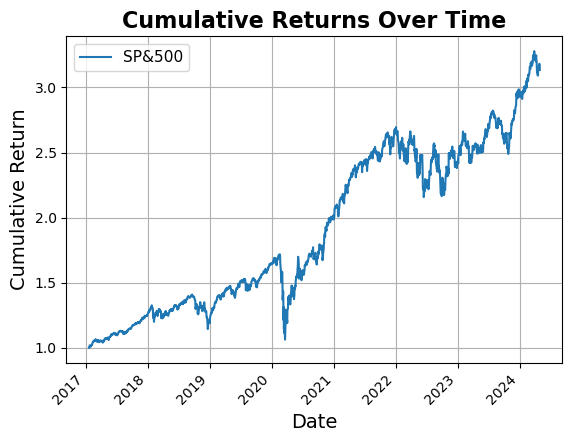

The CAGR is: 16.91%
Sharpe Ratio of Strategy: 0.89


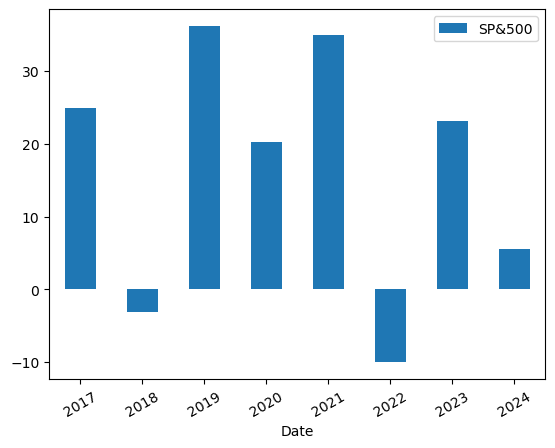

In [40]:
# Compute performance metrics based on the predictions and actual returns.
# - Use the 'func_lib.compute_BM_Perf()' function to calculate cumulative and calendar returns.
# - Pass the DataFrame 'y_test_and_pred' containing the actual and predicted values as an argument.
cum_returns, calendar_returns = func_lib.compute_BM_Perf(y_test_and_pred)

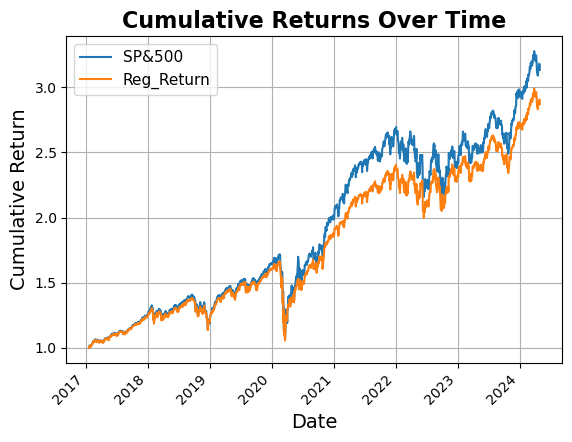

The CAGR is: 15.51%
Sharpe Ratio of Strategy: 0.91


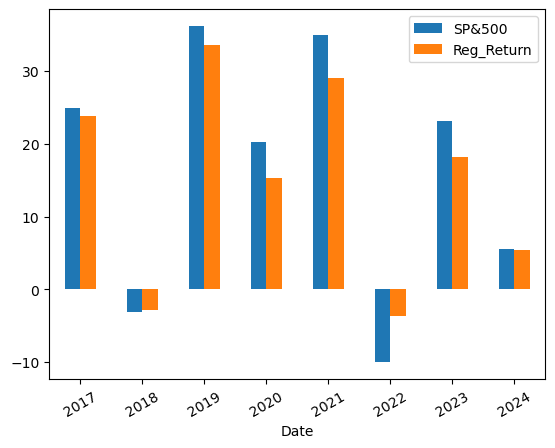

In [41]:
# Compute strategy performance metrics.
# - Use the 'func_lib.compute_strat_perf()' function to calculate the performance of the trading strategy.
# - Pass the following arguments:
#   - 'y_test_and_pred': The DataFrame containing actual and predicted values.
#   - 'cum_returns': Cumulative returns calculated previously.
#   - 'calendar_returns': Calendar returns calculated previously.
#   - 'trading_strategy': The function defining the trading strategy based on predictions.
#   - 'model_name': The name of the model to include in the performance evaluation.
cum_returns, calendar_returns = func_lib.compute_strat_perf(
    y_test_and_pred, cum_returns, calendar_returns, trading_strategy, model_name
)